# OULAD Advanced Models Report

## Purpose

This notebook documents the advanced-modeling part of the OULAD project. The goal is to compare several non-baseline pipelines for early student-risk prediction using week-based cutoffs from the engineered feature tables.

## What This Notebook Shows

- extraction and availability checks for the raw OULAD files
- loading of previously saved reference pipelines
- tuning and benchmarking of advanced models across `week2`, `week4`, `week6`, and `week8`
- comparison using Accuracy, Precision, Recall, F1, AUC, and cross-validation statistics
- ablation analysis to separate the effect of demographics and engagement features
- optional saving of tuned artifacts for reproducibility

The notebook is written in report style so that the outputs can be discussed directly in a presentation or technical handoff.

In [2]:
from pathlib import Path
import zipfile

def find_project_root(required_paths):
    search_roots = [Path.cwd(), *Path.cwd().parents]
    candidates = search_roots + [root / 'ELEN4025_Group_Assignment' for root in search_roots]

    for candidate in candidates:
        if all((candidate / relative_path).exists() for relative_path in required_paths):
            return candidate

    missing = ', '.join(required_paths)
    raise FileNotFoundError(f"Could not find a project folder containing: {missing}")

project_dir = find_project_root(['anonymisedData.zip'])
zip_file_path = project_dir / 'anonymisedData.zip'
required_files = ['studentInfo.csv', 'studentVle.csv', 'vle.csv']

print(f"Using project directory: {project_dir}")

if all((project_dir / file_name).exists() for file_name in required_files):
    print("Datasets already extracted. Skipping extraction step.")
else:
    print("Extracting datasets ...")
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(project_dir)
    print("Extraction complete.")

Using project directory: c:\Users\Wits-user\OneDrive\Documents\A. A machine learning project\ELEN4025_Group_Assignment
Datasets already extracted. Skipping extraction step.


## Data Preparation Context

The project uses `anonymisedData.zip` as the raw source bundle. Earlier project stages produced the cutoff-specific files in `data/interim/` and the engineered feature tables in `data/processed/`.

For the advanced-model experiments, the key inputs are the processed tables `week2_features.csv`, `week4_features.csv`, `week6_features.csv`, and `week8_features.csv`. Each table contains one row per student-module-presentation record, demographic features, cumulative engagement features up to the selected cutoff, and the binary label used for prediction.

## Previously Saved Reference Pipelines

Before fitting tuned models, the notebook loads the supplied saved pipelines. These serve as reference artifacts from earlier experimentation and make it possible to compare the final tuned workflow against the versions that already exist in the repository.

In [3]:
from pathlib import Path
import joblib
import warnings

def find_project_root(required_paths):
    search_roots = [Path.cwd(), *Path.cwd().parents]
    candidates = search_roots + [root / 'ELEN4025_Group_Assignment' for root in search_roots]

    for candidate in candidates:
        if all((candidate / relative_path).exists() for relative_path in required_paths):
            return candidate

    missing = ', '.join(required_paths)
    raise FileNotFoundError(f"Could not find a project folder containing: {missing}")

try:
    from sklearn.exceptions import InconsistentVersionWarning
except Exception:
    InconsistentVersionWarning = None

if InconsistentVersionWarning is not None:
    warnings.filterwarnings('ignore', category=InconsistentVersionWarning)

project_dir = find_project_root(['models'])
model_dir = project_dir / 'models'
pipelines = {}
load_errors = {}
missing_packages = set()

for model_file in sorted(model_dir.glob('*.pkl')):
    model_name = model_file.stem
    try:
        pipelines[model_name] = joblib.load(model_file)
    except ModuleNotFoundError as exc:
        missing_packages.add(exc.name)
        load_errors[model_name] = f"Missing package: {exc.name}"
    except Exception as exc:
        load_errors[model_name] = f"{type(exc).__name__}: {exc}"

print(f"Loaded {len(pipelines)} pipelines: {list(pipelines)}")

if load_errors:
    print("Skipped pipelines:")
    for model_name, error_message in load_errors.items():
        print(f" - {model_name}: {error_message}")

if missing_packages:
    package_list = ' '.join(sorted(missing_packages))
    print(f"Install missing libraries to load every saved model: pip install {package_list}")

Loaded 7 pipelines: ['pipeline_1_rf_calibrated', 'pipeline_2_gbm', 'pipeline_3_logreg_weighted_balanced', 'pipeline_4_rf_model-weighted_balance', 'pipeline_5_catboost', 'pipeline_6_knn', 'pipeline_7_xgboost']


## Advanced Model Benchmark

### Experimental Objective

The purpose of this section is to evaluate whether more advanced or self-learned models improve early risk prediction as more weeks of student activity become available.

### Models Included

- training the advanced pipelines across `week2`, `week4`, `week6`, and `week8`
- benchmarking Random Forest, Gradient Boosting, weighted Random Forest, CatBoost, KNN, and XGBoost
- tuning model hyperparameters with `RandomizedSearchCV`
- reporting Accuracy, Precision, Recall, F1, AUC, validation threshold, and cross-validation summaries
- identifying the best advanced model per cutoff
- saving reproducible comparison tables to `data/processed/`

### Evaluation Design

Each cutoff is evaluated separately. The workflow uses train, validation, and test splits, selects a classification threshold from the validation set, and then reports final holdout performance on the untouched test set. Cross-validation is also included to show whether performance is stable across folds rather than dependent on one random split.

The full benchmark is compute-intensive. You can reduce `SEARCH_ITERATIONS`, `CV_SPLITS`, `BENCHMARK_WEEKS`, or `BENCHMARK_MODELS` in the config cell for quicker experiments.

In [4]:
if 'find_project_root' not in globals():
    from pathlib import Path

    def find_project_root(required_paths):
        search_roots = [Path.cwd(), *Path.cwd().parents]
        candidates = search_roots + [root / 'ELEN4025_Group_Assignment' for root in search_roots]

        for candidate in candidates:
            if all((candidate / relative_path).exists() for relative_path in required_paths):
                return candidate

        missing = ', '.join(required_paths)
        raise FileNotFoundError(f"Could not find a project folder containing: {missing}")

import json
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier
from IPython.display import display
from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, f1_score, make_scorer, precision_recall_curve, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_validate, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier

BENCHMARK_WEEKS = ['week2', 'week4', 'week6', 'week8']
BENCHMARK_MODELS = [
    'pipeline_1_rf_calibrated.pkl',
    'pipeline_2_gbm.pkl',
    'pipeline_4_rf_model-weighted_balance.pkl',
    'pipeline_5_catboost.pkl',
    'pipeline_6_knn.pkl',
    'pipeline_7_xgboost.pkl',
]

SEARCH_ITERATIONS = 4
CV_SPLITS = 3
TEST_SIZE = 0.2
VALIDATION_SIZE = 0.25
RANDOM_STATE = 42

SAVE_BENCHMARK_TABLES = True
SAVE_TRAINED_MODELS = False

project_dir = find_project_root(['data/processed', 'models'])
processed_dir = project_dir / 'data' / 'processed'
model_output_root = project_dir / 'models'

benchmark_output_path = processed_dir / 'advanced_model_benchmark.csv'
best_model_output_path = processed_dir / 'advanced_model_best_per_week.csv'
ablation_output_path = processed_dir / 'advanced_model_ablation.csv'

print(f'Project directory: {project_dir}')
print(f'Benchmark weeks: {BENCHMARK_WEEKS}')
print(f'Benchmark models: {BENCHMARK_MODELS}')
print(f'Search iterations per model: {SEARCH_ITERATIONS}')
print(f'Cross-validation folds: {CV_SPLITS}')

Project directory: c:\Users\Wits-user\OneDrive\Documents\A. A machine learning project\ELEN4025_Group_Assignment
Benchmark weeks: ['week2', 'week4', 'week6', 'week8']
Benchmark models: ['pipeline_1_rf_calibrated.pkl', 'pipeline_2_gbm.pkl', 'pipeline_4_rf_model-weighted_balance.pkl', 'pipeline_5_catboost.pkl', 'pipeline_6_knn.pkl', 'pipeline_7_xgboost.pkl']
Search iterations per model: 4
Cross-validation folds: 3


In [5]:
ID_COLUMNS = ['id_student', 'code_module', 'code_presentation']
TARGET_COLUMN = 'label'

SCORING = {
    'accuracy': 'accuracy',
    'precision': make_scorer(precision_score, zero_division=0),
    'recall': make_scorer(recall_score, zero_division=0),
    'f1': make_scorer(f1_score, zero_division=0),
    'roc_auc': 'roc_auc',
}


def default_catboost_params():
    return {
        'loss_function': 'Logloss',
        'eval_metric': 'AUC',
        'auto_class_weights': 'Balanced',
        'random_state': RANDOM_STATE,
        'verbose': False,
    }


def json_safe(value):
    if isinstance(value, (np.integer, np.floating)):
        return value.item()
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, (list, tuple)):
        return [json_safe(item) for item in value]
    if isinstance(value, dict):
        return {key: json_safe(item) for key, item in value.items()}
    return value


def serialize_params(params):
    return json.dumps(json_safe(params), sort_keys=True)


def get_search_iterations(search_space):
    total = 1
    for values in search_space.values():
        total *= len(values)
    return max(1, min(SEARCH_ITERATIONS, total))


def load_week_dataset(week):
    dataset_path = processed_dir / f'{week}_features.csv'
    dataset = pd.read_csv(dataset_path)
    return dataset


def make_preprocessor(numeric_columns, categorical_columns):
    transformers = []

    if numeric_columns:
        transformers.append(
            (
                'num',
                Pipeline(
                    steps=[
                        ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
                        ('scaler', StandardScaler()),
                    ]
                ),
                numeric_columns,
            )
        )

    if categorical_columns:
        transformers.append(
            (
                'cat',
                Pipeline(
                    steps=[
                        ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
                        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
                    ]
                ),
                categorical_columns,
            )
        )

    return ColumnTransformer(transformers=transformers, remainder='drop')


def prepare_catboost_frame(frame, categorical_columns):
    prepared = frame.copy()
    for column in categorical_columns:
        prepared[column] = prepared[column].fillna('Missing').astype(str)
    return prepared


def get_feature_plan(week, feature_columns, X_frame):
    full_categorical_columns = [column for column in feature_columns if X_frame[column].dtype == 'object']
    full_numeric_columns = [column for column in feature_columns if column not in full_categorical_columns]

    base_numeric_columns = [
        column
        for column in [
            f'total_clicks_{week}',
            f'active_days_{week}',
            f'forumng_clicks_{week}',
            f'resource_clicks_{week}',
            'num_of_prev_attempts',
        ]
        if column in feature_columns
    ]
    base_categorical_columns = [
        column for column in ['gender', 'region', 'highest_education'] if column in feature_columns
    ]

    alt_numeric_columns = [
        column
        for column in [
            f'total_clicks_{week}',
            f'active_days_{week}',
            f'forumng_clicks_{week}',
            'studied_credits',
            'num_of_prev_attempts',
        ]
        if column in feature_columns
    ]
    alt_categorical_columns = [column for column in ['imd_band'] if column in feature_columns]

    engagement_only = [column for column in feature_columns if column.endswith(f'_{week}')]
    demographics_only = [column for column in feature_columns if column not in engagement_only]

    return {
        'feature_columns': feature_columns,
        'full_categorical_columns': full_categorical_columns,
        'full_numeric_columns': full_numeric_columns,
        'base_numeric_columns': base_numeric_columns,
        'base_categorical_columns': base_categorical_columns,
        'alt_numeric_columns': alt_numeric_columns,
        'alt_categorical_columns': alt_categorical_columns,
        'engagement_only': engagement_only,
        'demographics_only': demographics_only,
    }


def make_week_split(dataset, week):
    feature_columns = [column for column in dataset.columns if column not in ID_COLUMNS + [TARGET_COLUMN]]
    X = dataset[feature_columns].copy()
    y = dataset[TARGET_COLUMN].astype(int)
    feature_plan = get_feature_plan(week, feature_columns, X)

    X_dev, X_test, y_dev, y_test = train_test_split(
        X,
        y,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=y,
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_dev,
        y_dev,
        test_size=VALIDATION_SIZE,
        random_state=RANDOM_STATE,
        stratify=y_dev,
    )

    return {
        'X': X,
        'y': y,
        'feature_columns': feature_columns,
        'feature_plan': feature_plan,
        'X_train': X_train,
        'X_val': X_val,
        'X_dev': X_dev,
        'X_test': X_test,
        'y_train': y_train,
        'y_val': y_val,
        'y_dev': y_dev,
        'y_test': y_test,
    }


def build_model_specs(week, split_data):
    plan = split_data['feature_plan']

    return {
        'pipeline_1_rf_calibrated.pkl': {
            'kind': 'sklearn',
            'estimator': Pipeline(
                steps=[
                    ('preprocessor', make_preprocessor(plan['base_numeric_columns'], plan['base_categorical_columns'])),
                    (
                        'classifier',
                        CalibratedClassifierCV(
                            estimator=RandomForestClassifier(
                                class_weight='balanced',
                                random_state=RANDOM_STATE,
                                n_jobs=1,
                            ),
                            method='sigmoid',
                            cv=3,
                        ),
                    ),
                ]
            ),
            'search_space': {
                'classifier__estimator__n_estimators': [200, 400],
                'classifier__estimator__max_depth': [8, 12, None],
                'classifier__estimator__min_samples_leaf': [1, 2, 4],
                'classifier__estimator__min_samples_split': [2, 5, 10],
            },
        },
        'pipeline_2_gbm.pkl': {
            'kind': 'sklearn',
            'estimator': Pipeline(
                steps=[
                    ('preprocessor', make_preprocessor(plan['base_numeric_columns'], plan['base_categorical_columns'])),
                    ('classifier', GradientBoostingClassifier(random_state=RANDOM_STATE)),
                ]
            ),
            'search_space': {
                'classifier__n_estimators': [150, 250, 350],
                'classifier__learning_rate': [0.03, 0.05, 0.1],
                'classifier__max_depth': [2, 3, 4],
                'classifier__subsample': [0.8, 1.0],
            },
        },
        'pipeline_4_rf_model-weighted_balance.pkl': {
            'kind': 'sklearn',
            'estimator': Pipeline(
                steps=[
                    ('preprocessor', make_preprocessor(plan['full_numeric_columns'], [])),
                    (
                        'classifier',
                        RandomForestClassifier(
                            class_weight='balanced',
                            random_state=RANDOM_STATE,
                            n_jobs=1,
                        ),
                    ),
                ]
            ),
            'search_space': {
                'classifier__n_estimators': [250, 500],
                'classifier__max_depth': [10, 16, None],
                'classifier__min_samples_leaf': [1, 2, 4],
                'classifier__min_samples_split': [2, 5, 10],
            },
        },
        'pipeline_5_catboost.pkl': {
            'kind': 'catboost',
            'estimator': CatBoostClassifier(**default_catboost_params()),
            'feature_columns': plan['feature_columns'],
            'cat_features': plan['full_categorical_columns'],
            'search_space': {
                'depth': [4, 6, 8],
                'learning_rate': [0.03, 0.05, 0.1],
                'iterations': [300, 500, 700],
                'l2_leaf_reg': [1, 3, 5, 7],
            },
        },
        'pipeline_6_knn.pkl': {
            'kind': 'sklearn',
            'estimator': Pipeline(
                steps=[
                    ('preprocessor', make_preprocessor(plan['alt_numeric_columns'], plan['alt_categorical_columns'])),
                    ('classifier', KNeighborsClassifier()),
                ]
            ),
            'search_space': {
                'classifier__n_neighbors': [11, 21, 31],
                'classifier__weights': ['uniform', 'distance'],
                'classifier__p': [1, 2],
            },
        },
        'pipeline_7_xgboost.pkl': {
            'kind': 'sklearn',
            'estimator': Pipeline(
                steps=[
                    ('preprocessor', make_preprocessor(plan['alt_numeric_columns'], plan['alt_categorical_columns'])),
                    (
                        'classifier',
                        XGBClassifier(
                            eval_metric='logloss',
                            random_state=RANDOM_STATE,
                            n_jobs=1,
                        ),
                    ),
                ]
            ),
            'search_space': {
                'classifier__n_estimators': [150, 300, 500],
                'classifier__max_depth': [3, 4, 6],
                'classifier__learning_rate': [0.03, 0.05, 0.1],
                'classifier__subsample': [0.8, 0.9, 1.0],
                'classifier__colsample_bytree': [0.8, 0.9, 1.0],
            },
        },
    }


def select_best_threshold(y_true, probabilities):
    precision, recall, thresholds = precision_recall_curve(y_true, probabilities)
    if thresholds.size == 0:
        threshold = 0.5
        f1_value = f1_score(y_true, (probabilities >= threshold).astype(int), zero_division=0)
        return float(threshold), float(f1_value)

    numerator = 2 * precision[:-1] * recall[:-1]
    denominator = np.clip(precision[:-1] + recall[:-1], 1e-12, None)
    f1_scores = numerator / denominator
    best_index = int(np.nanargmax(f1_scores))
    return float(thresholds[best_index]), float(f1_scores[best_index])


def evaluate_probabilities(y_true, probabilities, threshold):
    predictions = (probabilities >= threshold).astype(int)
    return {
        'accuracy': float(accuracy_score(y_true, predictions)),
        'precision': float(precision_score(y_true, predictions, zero_division=0)),
        'recall': float(recall_score(y_true, predictions, zero_division=0)),
        'f1': float(f1_score(y_true, predictions, zero_division=0)),
        'auc': float(roc_auc_score(y_true, probabilities)),
    }


def summarize_cv_results(cv_results):
    summary = {}
    for metric_name in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
        values = cv_results[f'test_{metric_name}']
        summary[f'cv_{metric_name}_mean'] = float(np.mean(values))
        summary[f'cv_{metric_name}_std'] = float(np.std(values, ddof=0))
    return summary


def predict_probabilities(spec, estimator, X_frame):
    if spec['kind'] == 'catboost':
        prepared = prepare_catboost_frame(X_frame[spec['feature_columns']], spec['cat_features'])
        return estimator.predict_proba(prepared)[:, 1]
    return estimator.predict_proba(X_frame)[:, 1]


def tune_estimator(spec, X_train, y_train):
    cv = StratifiedKFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    n_iter = get_search_iterations(spec['search_space'])

    if spec['kind'] == 'catboost':
        prepared = prepare_catboost_frame(X_train[spec['feature_columns']], spec['cat_features'])
        search = RandomizedSearchCV(
            estimator=spec['estimator'],
            param_distributions=spec['search_space'],
            n_iter=n_iter,
            scoring='roc_auc',
            cv=cv,
            n_jobs=1,
            random_state=RANDOM_STATE,
            refit=True,
            error_score='raise',
        )
        search.fit(prepared, y_train, cat_features=spec['cat_features'], verbose=False)
        return search.best_estimator_, search.best_params_, float(search.best_score_)

    search = RandomizedSearchCV(
        estimator=spec['estimator'],
        param_distributions=spec['search_space'],
        n_iter=n_iter,
        scoring='roc_auc',
        cv=cv,
        n_jobs=1,
        random_state=RANDOM_STATE,
        refit=True,
        error_score='raise',
    )
    search.fit(X_train, y_train)
    return search.best_estimator_, search.best_params_, float(search.best_score_)


def cross_validate_estimator(spec, estimator, X_dev, y_dev):
    cv = StratifiedKFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)

    if spec['kind'] != 'catboost':
        cv_results = cross_validate(
            clone(estimator),
            X_dev,
            y_dev,
            cv=cv,
            scoring=SCORING,
            n_jobs=1,
            error_score='raise',
        )
        return summarize_cv_results(cv_results)

    fold_rows = []
    estimator_params = estimator.get_params()
    for train_index, valid_index in cv.split(X_dev, y_dev):
        fold_model = CatBoostClassifier(**estimator_params)
        X_fold_train = prepare_catboost_frame(X_dev.iloc[train_index][spec['feature_columns']], spec['cat_features'])
        X_fold_valid = prepare_catboost_frame(X_dev.iloc[valid_index][spec['feature_columns']], spec['cat_features'])
        y_fold_train = y_dev.iloc[train_index]
        y_fold_valid = y_dev.iloc[valid_index]

        fold_model.fit(X_fold_train, y_fold_train, cat_features=spec['cat_features'], verbose=False)
        fold_probabilities = fold_model.predict_proba(X_fold_valid)[:, 1]
        fold_rows.append(evaluate_probabilities(y_fold_valid, fold_probabilities, 0.5))

    cv_frame = pd.DataFrame(fold_rows)
    return {
        'cv_accuracy_mean': float(cv_frame['accuracy'].mean()),
        'cv_accuracy_std': float(cv_frame['accuracy'].std(ddof=0)),
        'cv_precision_mean': float(cv_frame['precision'].mean()),
        'cv_precision_std': float(cv_frame['precision'].std(ddof=0)),
        'cv_recall_mean': float(cv_frame['recall'].mean()),
        'cv_recall_std': float(cv_frame['recall'].std(ddof=0)),
        'cv_f1_mean': float(cv_frame['f1'].mean()),
        'cv_f1_std': float(cv_frame['f1'].std(ddof=0)),
        'cv_roc_auc_mean': float(cv_frame['auc'].mean()),
        'cv_roc_auc_std': float(cv_frame['auc'].std(ddof=0)),
    }


def refit_estimator(spec, best_params, X_dev, y_dev):
    if spec['kind'] == 'catboost':
        params = spec['estimator'].get_params()
        params.update(best_params)
        final_model = CatBoostClassifier(**params)
        prepared = prepare_catboost_frame(X_dev[spec['feature_columns']], spec['cat_features'])
        final_model.fit(prepared, y_dev, cat_features=spec['cat_features'], verbose=False)
        return final_model

    final_model = clone(spec['estimator']).set_params(**best_params)
    final_model.fit(X_dev, y_dev)
    return final_model

## Benchmark Execution And Reading Guide

The next cell executes the full benchmarking loop for the selected advanced models and week cutoffs.

### Main Deliverables Produced By The Cell

- `final_comparison_table`, which is the main report-style comparison table
- `best_models_display`, which identifies the strongest advanced model for each cutoff
- optional CSV outputs for direct inclusion in the final project submission

### How To Read The Results

A strong presentation should discuss more than accuracy alone. In this notebook, `Precision`, `Recall`, and `F1` describe the quality of at-risk predictions, `AUC` captures ranking strength across thresholds, and the `CV` columns show whether the model remains stable across multiple folds instead of performing well on only one split.

In [10]:
benchmark_rows = []
trained_artifacts = {}
week_splits = {}

for week in BENCHMARK_WEEKS:
    print(f'\n=== Benchmarking {week} ===')
    dataset = load_week_dataset(week)
    split_data = make_week_split(dataset, week)
    week_splits[week] = split_data
    model_specs = build_model_specs(week, split_data)

    print(f"Rows: {len(dataset):,} | Features: {len(split_data['feature_columns'])}")

    for model_name in BENCHMARK_MODELS:
        print(f'  Tuning and evaluating {model_name} ...')
        spec = model_specs[model_name]

        best_estimator, best_params, tuning_cv_auc = tune_estimator(spec, split_data['X_train'], split_data['y_train'])
        validation_probabilities = predict_probabilities(spec, best_estimator, split_data['X_val'])
        selected_threshold, validation_f1 = select_best_threshold(split_data['y_val'], validation_probabilities)
        test_probabilities = predict_probabilities(spec, best_estimator, split_data['X_test'])
        holdout_metrics = evaluate_probabilities(split_data['y_test'], test_probabilities, selected_threshold)
        cv_summary = cross_validate_estimator(spec, best_estimator, split_data['X_dev'], split_data['y_dev'])
        final_estimator = refit_estimator(spec, best_params, split_data['X_dev'], split_data['y_dev'])

        benchmark_rows.append(
            {
                'week': week,
                'model': model_name,
                'best_params': serialize_params(best_params),
                'selected_threshold': float(selected_threshold),
                'validation_f1': float(validation_f1),
                'tuning_cv_auc': float(tuning_cv_auc),
                **holdout_metrics,
                **cv_summary,
            }
        )

        trained_artifacts[(week, model_name)] = {
            'kind': spec['kind'],
            'estimator': final_estimator,
            'threshold': float(selected_threshold),
            'best_params': json_safe(best_params),
            'feature_columns': split_data['feature_columns'],
            'cat_features': spec.get('cat_features', []),
        }

benchmark_results = pd.DataFrame(benchmark_rows).sort_values(['week', 'auc', 'f1'], ascending=[True, False, False]).reset_index(drop=True)

final_comparison_table = benchmark_results[
    [
        'week',
        'model',
        'best_params',
        'selected_threshold',
        'accuracy',
        'precision',
        'recall',
        'f1',
        'auc',
        'cv_accuracy_mean',
        'cv_precision_mean',
        'cv_recall_mean',
        'cv_f1_mean',
        'cv_roc_auc_mean',
    ]
].rename(
    columns={
        'week': 'Week',
        'model': 'Model',
        'best_params': 'Best params',
        'selected_threshold': 'Threshold',
        'accuracy': 'Accuracy',
        'precision': 'Precision',
        'recall': 'Recall',
        'f1': 'F1',
        'auc': 'AUC',
        'cv_accuracy_mean': 'CV Accuracy',
        'cv_precision_mean': 'CV Precision',
        'cv_recall_mean': 'CV Recall',
        'cv_f1_mean': 'CV F1',
        'cv_roc_auc_mean': 'CV AUC',
    }
)

best_models_per_week = benchmark_results.sort_values(['week', 'auc', 'f1'], ascending=[True, False, False]).groupby('week', as_index=False).first()
best_models_per_week['why_best'] = best_models_per_week.apply(
    lambda row: f"Highest holdout AUC ({row['auc']:.3f}) with F1 {row['f1']:.3f} at threshold {row['selected_threshold']:.2f}",
    axis=1,
)

best_models_display = best_models_per_week[
    ['week', 'model', 'best_params', 'accuracy', 'precision', 'recall', 'f1', 'auc', 'cv_roc_auc_mean', 'why_best']
].rename(
    columns={
        'week': 'Week',
        'model': 'Best model',
        'best_params': 'Best params',
        'accuracy': 'Accuracy',
        'precision': 'Precision',
        'recall': 'Recall',
        'f1': 'F1',
        'auc': 'AUC',
        'cv_roc_auc_mean': 'CV AUC',
        'why_best': 'Why this model won',
    }
)

display(final_comparison_table)
display(best_models_display)

if SAVE_BENCHMARK_TABLES:
    final_comparison_table.to_csv(benchmark_output_path, index=False)
    best_models_display.to_csv(best_model_output_path, index=False)
    print(f'Saved benchmark table to {benchmark_output_path}')
    print(f'Saved best-per-week table to {best_model_output_path}')


=== Benchmarking week2 ===
Rows: 32,593 | Features: 18
  Tuning and evaluating pipeline_1_rf_calibrated.pkl ...
  Tuning and evaluating pipeline_2_gbm.pkl ...
  Tuning and evaluating pipeline_4_rf_model-weighted_balance.pkl ...
  Tuning and evaluating pipeline_5_catboost.pkl ...
  Tuning and evaluating pipeline_6_knn.pkl ...
  Tuning and evaluating pipeline_7_xgboost.pkl ...

=== Benchmarking week4 ===
Rows: 32,593 | Features: 18
  Tuning and evaluating pipeline_1_rf_calibrated.pkl ...
  Tuning and evaluating pipeline_2_gbm.pkl ...
  Tuning and evaluating pipeline_4_rf_model-weighted_balance.pkl ...
  Tuning and evaluating pipeline_5_catboost.pkl ...
  Tuning and evaluating pipeline_6_knn.pkl ...
  Tuning and evaluating pipeline_7_xgboost.pkl ...

=== Benchmarking week6 ===
Rows: 32,593 | Features: 18
  Tuning and evaluating pipeline_1_rf_calibrated.pkl ...
  Tuning and evaluating pipeline_2_gbm.pkl ...
  Tuning and evaluating pipeline_4_rf_model-weighted_balance.pkl ...
  Tuning and 

,Week,Model,Best params,Threshold,Accuracy,Precision,Recall,F1,AUC,CV Accuracy,CV Precision,CV Recall,CV F1,CV AUC
0,week2,pipeline_5_catboost.pkl,"{""depth"": 4, ""iterations"": 300, ""l2_leaf_reg"":...",0.395987,0.688756,0.620515,0.876828,0.726734,0.781706,0.699355,0.659136,0.752274,0.702580,0.772872
1,week2,pipeline_7_xgboost.pkl,"{""classifier__colsample_bytree"": 0.8, ""classif...",0.326369,0.651634,0.583749,0.912902,0.712131,0.762460,0.682595,0.648738,0.714576,0.680056,0.750517
2,week2,pipeline_2_gbm.pkl,"{""classifier__learning_rate"": 0.03, ""classifie...",0.355849,0.663292,0.594676,0.900227,0.716225,0.760844,0.682519,0.654983,0.692558,0.673149,0.752266
3,week2,pipeline_4_rf_model-weighted_balance.pkl,"{""classifier__max_depth"": 10, ""classifier__min...",0.371843,0.652247,0.584622,0.909327,0.711688,0.759186,0.679220,0.634857,0.754468,0.689492,0.749372
4,week2,pipeline_1_rf_calibrated.pkl,"{""classifier__estimator__max_depth"": 8, ""class...",0.333670,0.657923,0.589668,0.905102,0.714103,0.758965,0.680640,0.653854,0.687846,0.670337,0.751181
5,week2,pipeline_6_knn.pkl,"{""classifier__n_neighbors"": 31, ""classifier__p...",0.322581,0.645651,0.580348,0.900227,0.705732,0.745930,0.673391,0.648593,0.672652,0.660389,0.738273
6,week4,pipeline_5_catboost.pkl,"{""depth"": 4, ""iterations"": 300, ""l2_leaf_reg"":...",0.406228,0.701641,0.632491,0.878128,0.735338,0.798920,0.712050,0.668225,0.774781,0.717535,0.791270
7,week4,pipeline_4_rf_model-weighted_balance.pkl,"{""classifier__max_depth"": 10, ""classifier__min...",0.425043,0.689216,0.621055,0.876178,0.726881,0.779091,0.695252,0.649127,0.771449,0.705006,0.770921
8,week4,pipeline_2_gbm.pkl,"{""classifier__learning_rate"": 0.03, ""classifie...",0.426392,0.690443,0.627868,0.844979,0.720421,0.775547,0.691723,0.658968,0.719289,0.687772,0.768643
9,week4,pipeline_7_xgboost.pkl,"{""classifier__colsample_bytree"": 0.8, ""classif...",0.400521,0.679399,0.614422,0.861228,0.717185,0.773652,0.691954,0.654998,0.734075,0.692284,0.765824


,Week,Best model,Best params,Accuracy,Precision,Recall,F1,AUC,CV AUC,Why this model won
0,week2,pipeline_5_catboost.pkl,"{""depth"": 4, ""iterations"": 300, ""l2_leaf_reg"":...",0.688756,0.620515,0.876828,0.726734,0.781706,0.772872,Highest holdout AUC (0.782) with F1 0.727 at t...
1,week4,pipeline_5_catboost.pkl,"{""depth"": 4, ""iterations"": 300, ""l2_leaf_reg"":...",0.701641,0.632491,0.878128,0.735338,0.798920,0.791270,Highest holdout AUC (0.799) with F1 0.735 at t...
2,week6,pipeline_5_catboost.pkl,"{""depth"": 4, ""iterations"": 300, ""l2_leaf_reg"":...",0.718362,0.652046,0.864803,0.743504,0.814183,0.806262,Highest holdout AUC (0.814) with F1 0.744 at t...
3,week8,pipeline_5_catboost.pkl,"{""depth"": 4, ""iterations"": 300, ""l2_leaf_reg"":...",0.733088,0.659280,0.899253,0.760792,0.833968,0.825743,Highest holdout AUC (0.834) with F1 0.761 at t...


Saved benchmark table to c:\Users\Wits-user\OneDrive\Documents\A. A machine learning project\ELEN4025_Group_Assignment\data\processed\advanced_model_benchmark.csv
Saved best-per-week table to c:\Users\Wits-user\OneDrive\Documents\A. A machine learning project\ELEN4025_Group_Assignment\data\processed\advanced_model_best_per_week.csv


## Threshold Sweep Across Models

The threshold sweep is presented for all benchmark models at `week8` in order to compare how the decision threshold affects classification behaviour when the largest amount of student engagement information is available. Since week 8 is the latest evaluated cutoff, it provides the most complete view of student activity and is therefore the most suitable point for comparing threshold behaviour across models.

For each model, the first graph shows how precision, recall, and F1 vary across candidate thresholds on the validation set, while the second graph shows the corresponding precision-recall curve with the selected threshold highlighted. Together, these plots illustrate how different models trade off between correctly identifying at-risk students and limiting false alarms.

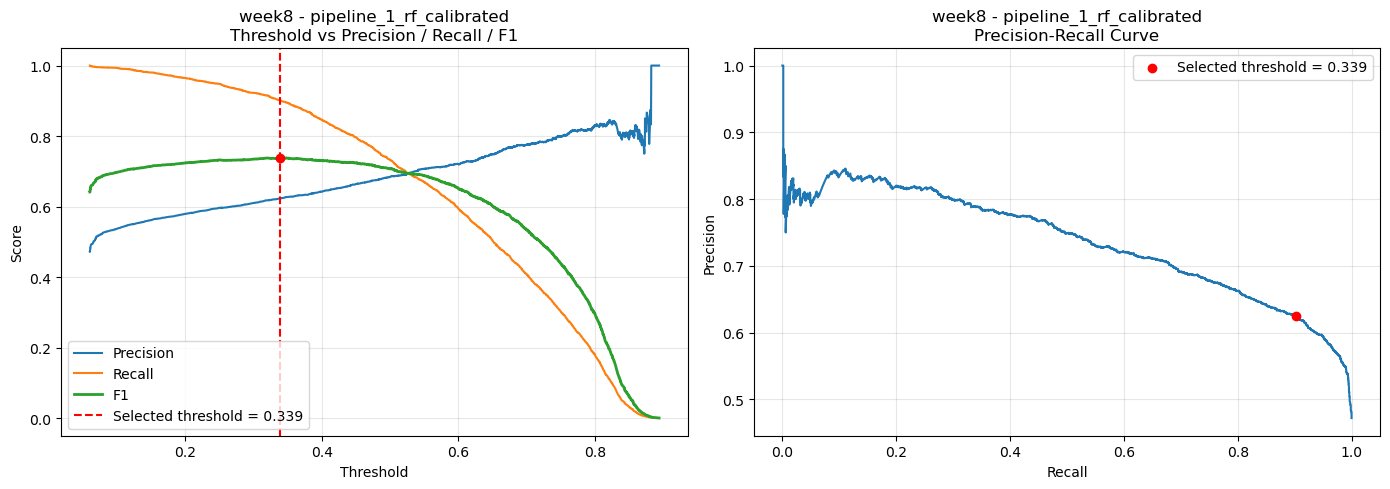

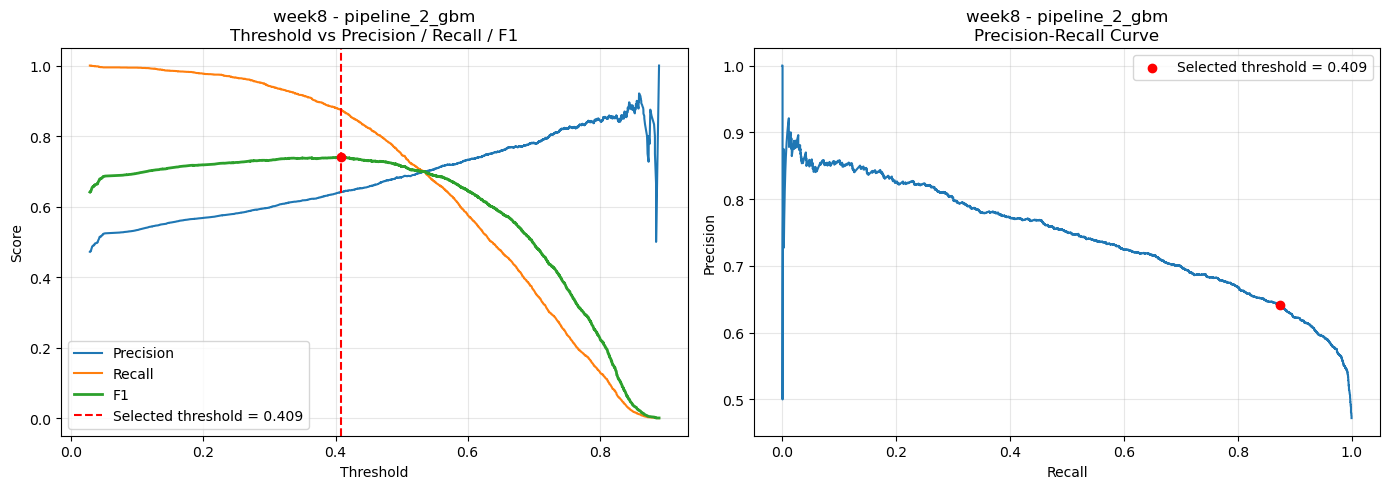

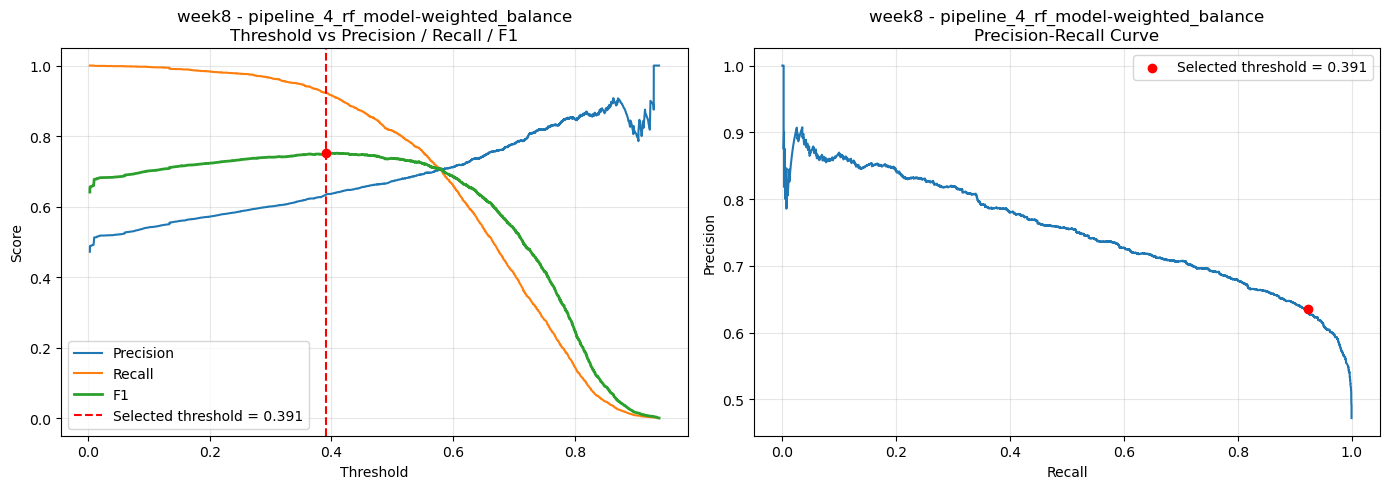

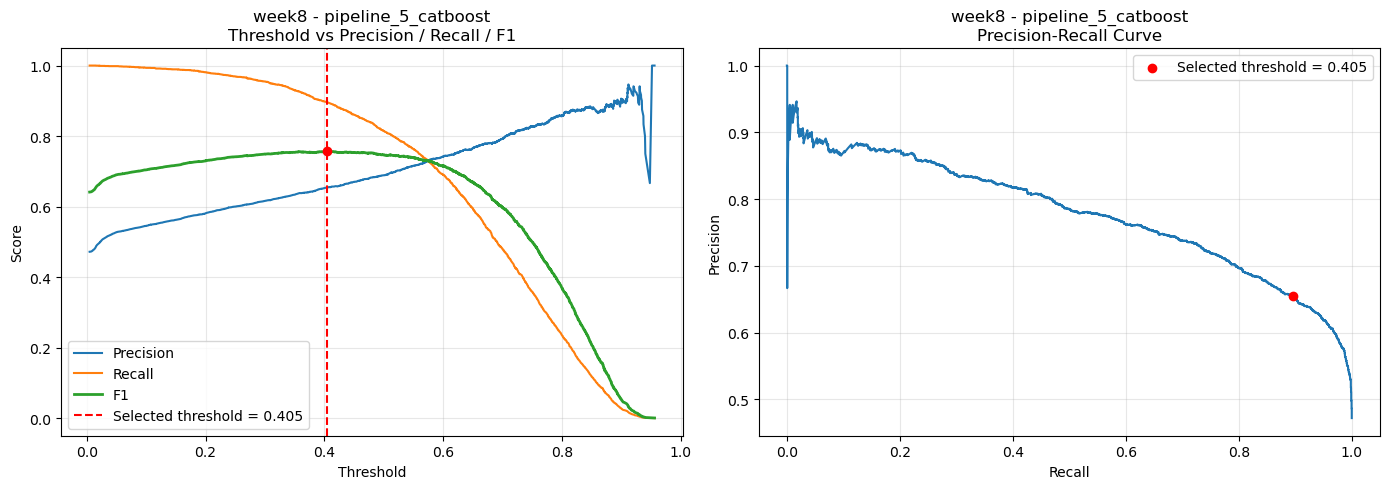

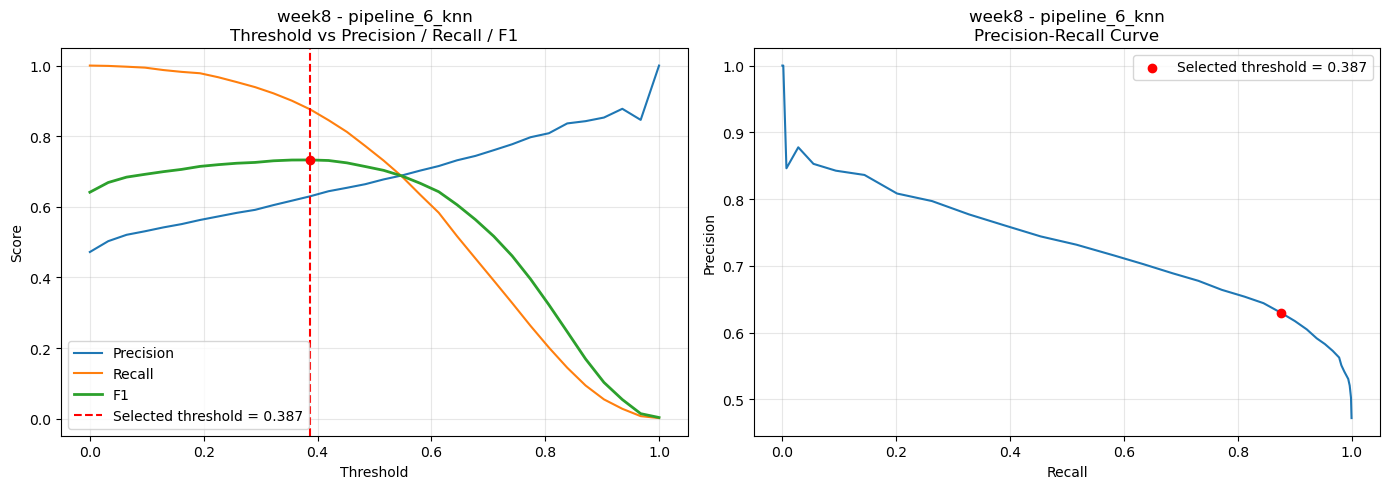

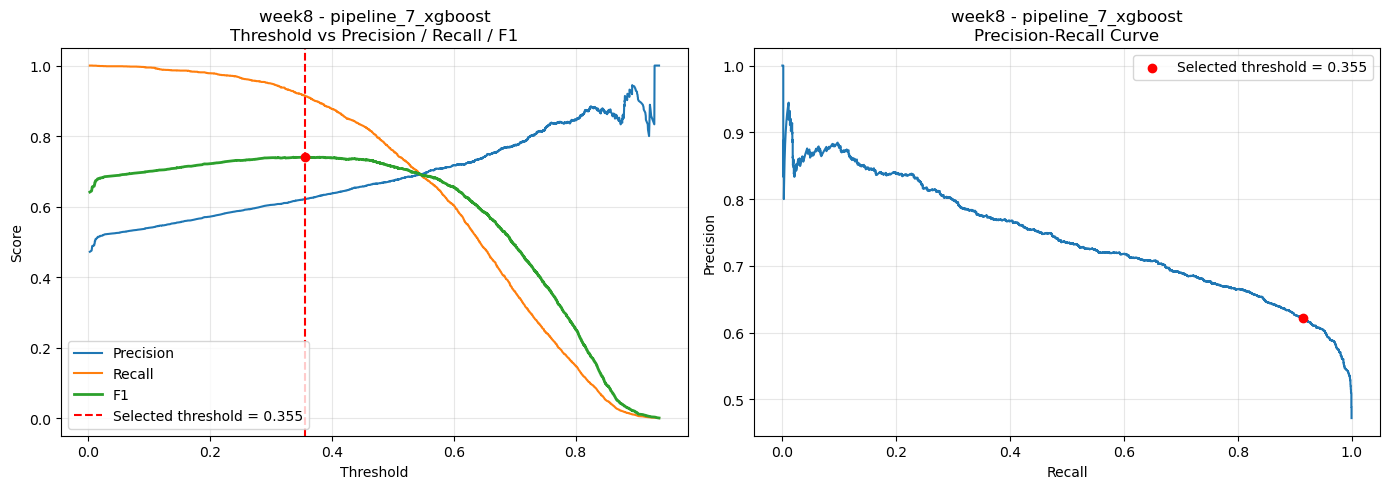

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import precision_recall_curve

WEEK_FOR_SWEEP = 'week8'
MODELS_FOR_SWEEP = BENCHMARK_MODELS.copy()

dataset = load_week_dataset(WEEK_FOR_SWEEP)
split_data = make_week_split(dataset, WEEK_FOR_SWEEP)
model_specs = build_model_specs(WEEK_FOR_SWEEP, split_data)

for model_name in MODELS_FOR_SWEEP:
    spec = model_specs[model_name]

    best_estimator, best_params, tuning_cv_auc = tune_estimator(
        spec,
        split_data['X_train'],
        split_data['y_train'],
    )

    validation_probabilities = predict_probabilities(
        spec,
        best_estimator,
        split_data['X_val'],
    )

    selected_threshold, validation_f1 = select_best_threshold(
        split_data['y_val'],
        validation_probabilities,
    )

    precision, recall, thresholds = precision_recall_curve(
        split_data['y_val'],
        validation_probabilities,
    )

    if thresholds.size == 0:
        continue

    precision_t = precision[:-1]
    recall_t = recall[:-1]
    f1_t = (
        2 * precision_t * recall_t
        / np.clip(precision_t + recall_t, 1e-12, None)
    )

    selected_idx = int(np.argmin(np.abs(thresholds - selected_threshold)))
    plot_name = model_name.replace('.pkl', '')

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(thresholds, precision_t, label='Precision')
    axes[0].plot(thresholds, recall_t, label='Recall')
    axes[0].plot(thresholds, f1_t, label='F1', linewidth=2)
    axes[0].axvline(
        selected_threshold,
        color='red',
        linestyle='--',
        label=f'Selected threshold = {selected_threshold:.3f}',
    )
    axes[0].scatter(
        thresholds[selected_idx],
        f1_t[selected_idx],
        color='red',
        zorder=3,
    )
    axes[0].set_xlabel('Threshold')
    axes[0].set_ylabel('Score')
    axes[0].set_title(f'{WEEK_FOR_SWEEP} - {plot_name}\nThreshold vs Precision / Recall / F1')
    axes[0].grid(alpha=0.3)
    axes[0].legend()

    axes[1].plot(recall, precision, color='tab:blue')
    axes[1].scatter(
        recall_t[selected_idx],
        precision_t[selected_idx],
        color='red',
        label=f'Selected threshold = {selected_threshold:.3f}',
        zorder=3,
    )
    axes[1].set_xlabel('Recall')
    axes[1].set_ylabel('Precision')
    axes[1].set_title(f'{WEEK_FOR_SWEEP} - {plot_name}\nPrecision-Recall Curve')
    axes[1].grid(alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

## Ablation Study

### Motivation

Overall benchmark performance tells us which model works best, but it does not show which feature groups are responsible for the gain. The ablation study addresses this by holding the model family fixed and changing only the available inputs.

This ablation uses CatBoost across all cutoffs to compare three feature groups:

- `demographics_only`
- `engagement_only`
- `combined_all`

In presentation terms, this section answers a practical question: how much predictive value comes from weekly engagement behaviour beyond static background information?

In [16]:
if 'benchmark_results' not in globals():
    raise RuntimeError('Run the advanced benchmark cell before the ablation cell.')

ablation_rows = []

for week in BENCHMARK_WEEKS:
    print(f'\n=== Ablation for {week} ===')
    split_data = week_splits.get(week)
    if split_data is None:
        split_data = make_week_split(load_week_dataset(week), week)

    catboost_row = benchmark_results[
        (benchmark_results['week'] == week) & (benchmark_results['model'] == 'pipeline_5_catboost.pkl')
    ].iloc[0]
    catboost_params = json.loads(catboost_row['best_params'])

    feature_sets = {
        'demographics_only': split_data['feature_plan']['demographics_only'],
        'engagement_only': split_data['feature_plan']['engagement_only'],
        'combined_all': split_data['feature_columns'],
    }

    for feature_set_name, selected_columns in feature_sets.items():
        print(f'  Training CatBoost ablation: {feature_set_name}')
        selected_columns = list(selected_columns)
        categorical_columns = [column for column in selected_columns if split_data['X'][column].dtype == 'object']

        ablation_model = CatBoostClassifier(**{**default_catboost_params(), **catboost_params})
        X_train = prepare_catboost_frame(split_data['X_train'][selected_columns], categorical_columns)
        X_val = prepare_catboost_frame(split_data['X_val'][selected_columns], categorical_columns)
        X_test = prepare_catboost_frame(split_data['X_test'][selected_columns], categorical_columns)

        ablation_model.fit(X_train, split_data['y_train'], cat_features=categorical_columns, verbose=False)
        validation_probabilities = ablation_model.predict_proba(X_val)[:, 1]
        selected_threshold, validation_f1 = select_best_threshold(split_data['y_val'], validation_probabilities)
        test_probabilities = ablation_model.predict_proba(X_test)[:, 1]
        holdout_metrics = evaluate_probabilities(split_data['y_test'], test_probabilities, selected_threshold)

        ablation_rows.append(
            {
                'week': week,
                'feature_set': feature_set_name,
                'feature_count': len(selected_columns),
                'selected_threshold': float(selected_threshold),
                'validation_f1': float(validation_f1),
                **holdout_metrics,
            }
        )

ablation_results = pd.DataFrame(ablation_rows).sort_values(['week', 'auc', 'f1'], ascending=[True, False, False]).reset_index(drop=True)
ablation_display = ablation_results.rename(
    columns={
        'week': 'Week',
        'feature_set': 'Feature set',
        'feature_count': 'Feature count',
        'selected_threshold': 'Threshold',
        'validation_f1': 'Validation F1',
        'accuracy': 'Accuracy',
        'precision': 'Precision',
        'recall': 'Recall',
        'f1': 'F1',
        'auc': 'AUC',
    }
)

display(ablation_display)

if SAVE_BENCHMARK_TABLES:
    ablation_display.to_csv(ablation_output_path, index=False)
    print(f'Saved ablation table to {ablation_output_path}')


=== Ablation for week2 ===
  Training CatBoost ablation: demographics_only
  Training CatBoost ablation: engagement_only
  Training CatBoost ablation: combined_all

=== Ablation for week4 ===
  Training CatBoost ablation: demographics_only
  Training CatBoost ablation: engagement_only
  Training CatBoost ablation: combined_all

=== Ablation for week6 ===
  Training CatBoost ablation: demographics_only
  Training CatBoost ablation: engagement_only
  Training CatBoost ablation: combined_all

=== Ablation for week8 ===
  Training CatBoost ablation: demographics_only
  Training CatBoost ablation: engagement_only
  Training CatBoost ablation: combined_all


,Week,Feature set,Feature count,Threshold,Validation F1,Accuracy,Precision,Recall,F1,AUC
0,week2,combined_all,18,0.384526,0.717922,0.682160,0.612592,0.888528,0.725199,0.780630
1,week2,engagement_only,10,0.381829,0.704012,0.642276,0.577880,0.898278,0.703308,0.747023
2,week2,demographics_only,8,0.346432,0.658134,0.544715,0.509825,0.919077,0.655844,0.660855
3,week4,combined_all,18,0.400459,0.731950,0.699034,0.629260,0.882028,0.734506,0.798615
4,week4,engagement_only,10,0.415346,0.720359,0.676944,0.610216,0.873578,0.718524,0.769333
5,week4,demographics_only,8,0.357524,0.658234,0.549317,0.512802,0.904777,0.654597,0.661072
6,week6,combined_all,18,0.439662,0.741954,0.720509,0.655746,0.858629,0.743597,0.813903
7,week6,engagement_only,10,0.414335,0.725982,0.686762,0.620153,0.868053,0.723456,0.786137
8,week6,demographics_only,8,0.346432,0.658134,0.544715,0.509825,0.919077,0.655844,0.660855
9,week8,combined_all,18,0.429525,0.757089,0.737843,0.667565,0.885603,0.761280,0.834281


Saved ablation table to c:\Users\khoza\Downloads\Machine_learning_group\ELEN4025_Group_Assignment\data\processed\advanced_model_ablation.csv


## Reproducibility And Deliverables

The benchmark workflow is designed to produce outputs that can be reused in later stages of the project. With `SAVE_BENCHMARK_TABLES = True`, the comparison tables are written into `data/processed/`. If tuned model artifacts are also needed for inspection or deployment-style follow-up, the next cell can save them as well.

Set `SAVE_TRAINED_MODELS = True` in the config cell if you want to save the tuned artifacts. They are written into week-specific folders such as `models/retrained_week4/` and include the tuned estimator plus metadata such as threshold and feature columns.

In [17]:
if SAVE_TRAINED_MODELS:
    for (week, model_name), artifact in trained_artifacts.items():
        output_dir = model_output_root / f'retrained_{week}'
        output_dir.mkdir(parents=True, exist_ok=True)

        payload = {
            'model': artifact['estimator'],
            'threshold': artifact['threshold'],
            'best_params': artifact['best_params'],
            'feature_columns': artifact['feature_columns'],
            'week': week,
        }
        if artifact['kind'] == 'catboost':
            payload['cat_features'] = artifact['cat_features']

        output_path = output_dir / model_name
        joblib.dump(payload, output_path)
        print(f'Saved {output_path}')
else:
    print('Saving is disabled. Set SAVE_TRAINED_MODELS = True in the config cell, rerun the benchmark cell, and then run this save cell.')

Saving is disabled. Set SAVE_TRAINED_MODELS = True in the config cell, rerun the benchmark cell, and then run this save cell.


## Error Analysis

This section examines the prediction errors made by the best-performing model in each evaluated week. The analysis below focuses on the remaining mistakes made on the test set.

The purpose of this section is to identify whether the strongest models are more affected by false positives or false negatives, whether some student subgroups are more difficult to classify than others, and whether misclassified students show distinct engagement or background patterns. This helps move the evaluation beyond summary metrics and towards a more interpretable understanding of model behaviour.

In [ ]:
required_objects = ['best_models_per_week', 'trained_artifacts', 'week_splits']
missing_objects = [name for name in required_objects if name not in globals()]

if missing_objects:
    raise NameError(
        "Missing required benchmark objects: "
        + ", ".join(missing_objects)
        + ". Run the benchmark cell first."
    )

SUBGROUP_COLUMN = 'highest_education'   

error_frames_by_week = {}
subgroup_tables_by_week = {}
mistake_profiles_by_week = {}
summary_rows = []

for _, row in best_models_per_week.iterrows():
    week = row['week']
    model_name = row['model']

    artifact = trained_artifacts[(week, model_name)]
    split_data = week_splits[week]

    spec = {
        'kind': artifact['kind'],
        'feature_columns': artifact['feature_columns'],
        'cat_features': artifact.get('cat_features', []),
    }

    test_probabilities = predict_probabilities(
        spec,
        artifact['estimator'],
        split_data['X_test'],
    )
    test_predictions = (test_probabilities >= artifact['threshold']).astype(int)

    week_data = load_week_dataset(week).loc[split_data['X_test'].index].copy()
    week_data['y_true'] = split_data['y_test'].to_numpy()
    week_data['y_pred'] = test_predictions
    week_data['probability'] = test_probabilities
    week_data['threshold'] = artifact['threshold']

    week_data['error_type'] = np.select(
        [
            (week_data['y_true'] == 1) & (week_data['y_pred'] == 1),
            (week_data['y_true'] == 0) & (week_data['y_pred'] == 0),
            (week_data['y_true'] == 0) & (week_data['y_pred'] == 1),
            (week_data['y_true'] == 1) & (week_data['y_pred'] == 0),
        ],
        ['TP', 'TN', 'FP', 'FN'],
        default='Unknown',
    )

    week_data['distance_from_threshold'] = np.abs(
        week_data['probability'] - artifact['threshold']
    )

    error_frames_by_week[week] = week_data

    counts = week_data['error_type'].value_counts()
    tp = int(counts.get('TP', 0))
    tn = int(counts.get('TN', 0))
    fp = int(counts.get('FP', 0))
    fn = int(counts.get('FN', 0))

    summary_rows.append(
        {
            'week': week,
            'model': model_name,
            'threshold': round(float(artifact['threshold']), 3),
            'TP': tp,
            'TN': tn,
            'FP': fp,
            'FN': fn,
            'FP_rate': round(fp / len(week_data), 3),
            'FN_rate': round(fn / len(week_data), 3),
        }
    )

    if SUBGROUP_COLUMN in week_data.columns:
        subgroup_table = (
            week_data.groupby([SUBGROUP_COLUMN, 'error_type'])
            .size()
            .unstack(fill_value=0)
            .reindex(columns=['TP', 'TN', 'FP', 'FN'], fill_value=0)
        )

        subgroup_table['group_total'] = subgroup_table[['TP', 'TN', 'FP', 'FN']].sum(axis=1)
        subgroup_table['FP_rate'] = (subgroup_table['FP'] / subgroup_table['group_total']).round(3)
        subgroup_table['FN_rate'] = (subgroup_table['FN'] / subgroup_table['group_total']).round(3)

        subgroup_tables_by_week[week] = subgroup_table.sort_values(
            ['FN_rate', 'FP_rate'], ascending=False
        )

    key_features = [
        feature for feature in [
            f'total_clicks_{week}',
            f'active_days_{week}',
            'num_of_prev_attempts',
            'studied_credits',
        ]
        if feature in week_data.columns
    ]

    mistakes = week_data[week_data['error_type'].isin(['FP', 'FN'])].copy()

    if not mistakes.empty and key_features:
        mistake_profiles_by_week[week] = (
            mistakes.groupby('error_type')[key_features].median().round(2)
        )
    else:
        mistake_profiles_by_week[week] = pd.DataFrame()

summary_frame = pd.DataFrame(summary_rows).sort_values('week').reset_index(drop=True)

print('Best-model error counts by week')
display(summary_frame)

for week in summary_frame['week']:
    model_name = summary_frame.loc[summary_frame['week'] == week, 'model'].iloc[0]

    print(f'\n{week} - {model_name}')

    if week in subgroup_tables_by_week:
        print(f'Subgroup breakdown by {SUBGROUP_COLUMN}')
        display(subgroup_tables_by_week[week])

    if not mistake_profiles_by_week[week].empty:
        print('Median feature values for false positives and false negatives')
        display(mistake_profiles_by_week[week])


Best-model error counts by week


,week,model,threshold,TP,TN,FP,FN,FP_rate,FN_rate
0,week2,pipeline_5_catboost.pkl,0.396,2692,1792,1650,385,0.253,0.059
1,week4,pipeline_5_catboost.pkl,0.406,2686,1863,1579,391,0.242,0.060
2,week6,pipeline_5_catboost.pkl,0.430,2650,2034,1408,427,0.216,0.066
3,week8,pipeline_5_catboost.pkl,0.405,2767,2028,1414,310,0.217,0.048



week2 - pipeline_5_catboost.pkl
Subgroup breakdown by highest_education


error_type,TP,TN,FP,FN,group_total,FP_rate,FN_rate
highest_education,,,,,,,
Lower Than A Level,815,1026,606,223,2670,0.227,0.084
No Formal quals,11,28,14,3,56,0.250,0.054
A Level or Equivalent,1328,561,765,127,2781,0.275,0.046
HE Qualification,493,170,245,31,939,0.261,0.033
Post Graduate Qualification,45,7,20,1,73,0.274,0.014


Median feature values for false positives and false negatives


...

,total_clicks_week6,active_days_week6,num_of_prev_attempts,studied_credits
error_type,,,,
FN,94.0,7.0,0.0,60.0
FP,324.0,18.0,0.0,60.0



week8 - pipeline_5_catboost.pkl
Subgroup breakdown by highest_education


error_type,TP,TN,FP,FN,group_total,FP_rate,FN_rate
highest_education,,,,,,,
Lower Than A Level,878,1090,542,160,2670,0.203,0.060
A Level or Equivalent,1336,693,633,119,2781,0.228,0.043
No Formal quals,12,29,13,2,56,0.232,0.036
HE Qualification,496,205,210,28,939,0.224,0.030
Post Graduate Qualification,45,11,16,1,73,0.219,0.014


Median feature values for false positives and false negatives


,total_clicks_week8,active_days_week8,num_of_prev_attempts,studied_credits
error_type,,,,
FN,111.5,9.0,0.0,60.0
FP,380.0,22.0,0.0,60.0
